# 04 — Modeling
**Input:** `data/processed/train.csv` and `data/processed/test.csv`

This notebook trains and evaluates two models on the same processed data:
1. **Regression** — predict the numeric `AQI` value
2. **Classification** — predict the `AQI_Bucket` category (Good / Moderate / Poor / etc.)

Both use Random Forest as a strong, fast baseline, then compare against one alternative algorithm each. The best model of each type is saved to `models/`.

## 1. Imports

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, f1_score, classification_report, confusion_matrix
)

FIG_DIR = "../reports/figures/"


## 2. Load processed data

In [2]:
train = pd.read_csv("../data/processed/train.csv")
test = pd.read_csv("../data/processed/test.csv")

print("Train shape:", train.shape)
print("Test shape:", test.shape)
train.head()


Train shape: (19882, 24)
Test shape: (4944, 24)


,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,...,AQI,AQI_Bucket,Year,Month,Day,DayOfWeek,Season,AQI_lag1,AQI_rolling7,AQI_Bucket_enc
0,Delhi,2015-01-02,1.874926,1.674775,1.985509,0.158381,1.819382,0.307637,1.019326,-0.442669,...,454.0,Severe,2015,1,2,4,Winter,472.0,463.000000,4
1,Delhi,2015-01-03,0.311785,0.147523,0.361886,0.053902,0.510654,1.765978,1.170805,-0.672365,...,143.0,Moderate,2015,1,3,5,Winter,454.0,356.333333,1
2,Delhi,2015-01-04,1.332721,1.367327,0.329735,0.323263,0.532471,4.117029,1.302464,-0.558665,...,319.0,Very Poor,2015,1,4,6,Winter,143.0,347.000000,5
3,Delhi,2015-01-05,1.249985,1.115356,-0.161461,0.242046,0.194788,3.827836,0.971192,-0.633317,...,325.0,Very Poor,2015,1,5,0,Winter,319.0,342.600000,5
4,Delhi,2015-01-06,1.297037,1.481164,-0.018568,0.361218,0.331880,4.295262,1.005169,-0.614367,...,318.0,Very Poor,2015,1,6,1,Winter,325.0,338.500000,5


## 3. Define feature columns and targets
`Date` isn't a usable numeric feature, and `AQI_Bucket` (the raw string label) shouldn't be a feature — only its encoded version `AQI_Bucket_enc` is a valid target.

In [39]:
drop_cols = ['Date', 'AQI_Bucket', 'AQI', 'AQI_Bucket_enc']
feature_cols = [c for c in train.columns if c not in drop_cols]

preprocessor = ColumnTransformer([
    ("numeric", SimpleImputer(strategy="median"), make_column_selector(dtype_include=np.number)),
    ("categorical", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]), make_column_selector(dtype_exclude=np.number))
])
scaled_preprocessor = ColumnTransformer([
    ("numeric", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), make_column_selector(dtype_include=np.number)),
    ("categorical", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]), make_column_selector(dtype_exclude=np.number))
])

X_train = train[feature_cols]
X_test = test[feature_cols]

y_train_reg = train['AQI']
y_test_reg = test['AQI']
reg_train_mask = y_train_reg.notna()
reg_test_mask = y_test_reg.notna()
X_train_reg = X_train.loc[reg_train_mask]
y_train_reg = y_train_reg.loc[reg_train_mask]
X_test_reg = X_test.loc[reg_test_mask]
y_test_reg = y_test_reg.loc[reg_test_mask]

train_clf_mask = train['AQI_Bucket'].notna() & train['AQI_Bucket_enc'].notna()
test_clf_mask = test['AQI_Bucket'].notna() & test['AQI_Bucket_enc'].notna()
X_train_clf = X_train.loc[train_clf_mask]
X_test_clf = X_test.loc[test_clf_mask]
y_train_clf = train.loc[train_clf_mask, 'AQI_Bucket_enc']
y_test_clf = test.loc[test_clf_mask, 'AQI_Bucket_enc']

print("Number of features:", len(feature_cols))
print("Regression rows with known AQI - train:", len(y_train_reg), "test:", len(y_test_reg))
print("Classification rows with known bucket - train:", len(y_train_clf), "test:", len(y_test_clf))
feature_cols


Number of features: 20
Regression rows with known AQI - train: 19465 test: 4878
Classification rows with known bucket - train: 19465 test: 4878


['City',
 'PM2.5',
 'PM10',
 'NO',
 'NO2',
 'NOx',
 'NH3',
 'CO',
 'SO2',
 'O3',
 'Benzene',
 'Toluene',
 'Xylene',
 'Year',
 'Month',
 'Day',
 'DayOfWeek',
 'Season',
 'AQI_lag1',
 'AQI_rolling7']

## 4. Regression — predicting AQI

### 4a. Baseline: Linear Regression

In [25]:
lr = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])
lr.fit(X_train_reg, y_train_reg)
lr_preds = lr.predict(X_test_reg)

print("Linear Regression:")
print("  MAE :", mean_absolute_error(y_test_reg, lr_preds))
print("  RMSE:", np.sqrt(mean_squared_error(y_test_reg, lr_preds)))
print("  R2  :", r2_score(y_test_reg, lr_preds))


Linear Regression:
  MAE : 14.900836161306284
  RMSE: 25.810306502669874
  R2  : 0.917898727674559


### 4b. Random Forest Regressor

In [26]:
rf_reg = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=200,
        max_depth=None,
        random_state=42,
        n_jobs=-1
    ))
])
rf_reg.fit(X_train_reg, y_train_reg)
rf_reg_preds = rf_reg.predict(X_test_reg)

print("Random Forest Regressor:")
print("  MAE :", mean_absolute_error(y_test_reg, rf_reg_preds))
print("  RMSE:", np.sqrt(mean_squared_error(y_test_reg, rf_reg_preds)))
print("  R2  :", r2_score(y_test_reg, rf_reg_preds))


Random Forest Regressor:
  MAE : 11.826783517835178
  RMSE: 21.98548374286893
  R2  : 0.9404289006039602


### 4c. Actual vs Predicted plot

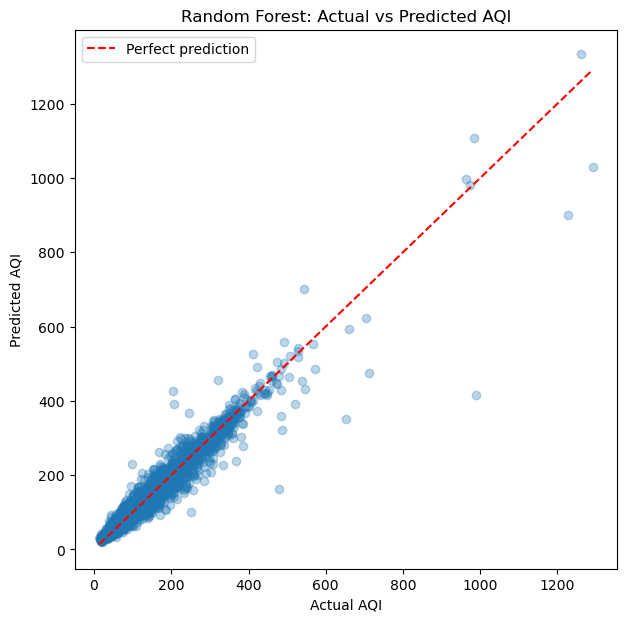

In [34]:
plt.figure(figsize=(7,7))
plt.scatter(y_test_reg, rf_reg_preds, alpha=0.3)
plt.plot([y_test_reg.min(), y_test_reg.max()],
         [y_test_reg.min(), y_test_reg.max()], 'r--', label='Perfect prediction')
plt.xlabel("Actual AQI")
plt.ylabel("Predicted AQI")
plt.title("Random Forest: Actual vs Predicted AQI")
plt.legend()
plt.savefig(FIG_DIR + "rf_actual_vs_predicted.png", dpi=150, bbox_inches='tight')
plt.show()


### 4d. Feature importance

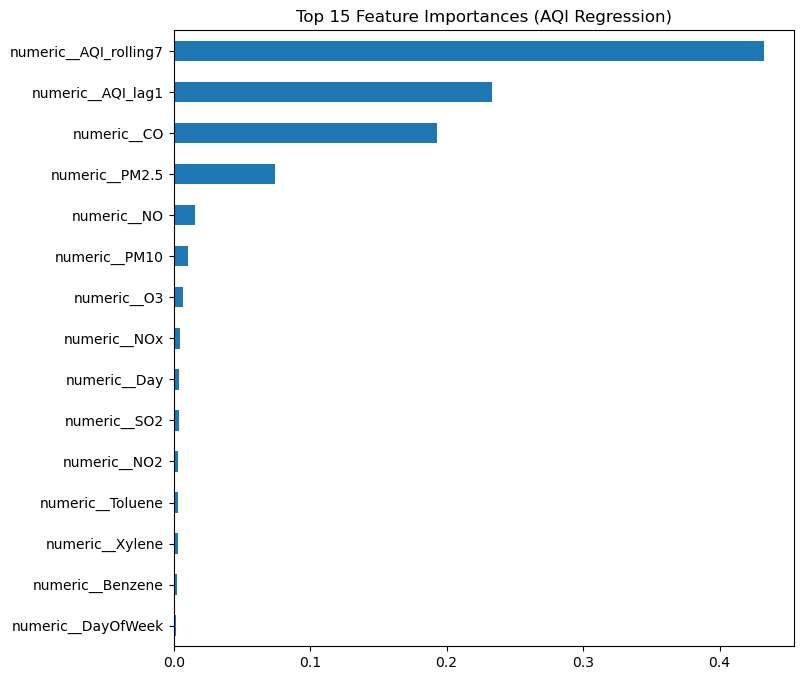

In [27]:
importances = pd.Series(
    rf_reg.named_steps["model"].feature_importances_,
    index=rf_reg.named_steps["preprocessor"].get_feature_names_out()
).sort_values(ascending=False)

plt.figure(figsize=(8,8))
importances.head(15).plot(kind='barh')
plt.gca().invert_yaxis()
plt.title("Top 15 Feature Importances (AQI Regression)")
plt.savefig(FIG_DIR + "feature_importance_regression.png", dpi=150, bbox_inches='tight')
plt.show()


## 5. Classification — predicting AQI_Bucket

### 5a. Baseline: Logistic Regression

In [40]:
log_clf = Pipeline([
    ("preprocessor", scaled_preprocessor),
    ("model", LogisticRegression(max_iter=2000))
])
log_clf.fit(X_train_clf, y_train_clf)
log_preds = log_clf.predict(X_test_clf)

print("Logistic Regression:")
print("  Accuracy:", accuracy_score(y_test_clf, log_preds))
print("  F1 (weighted):", f1_score(y_test_clf, log_preds, average='weighted'))


Logistic Regression:
  Accuracy: 0.8126281262812628
  F1 (weighted): 0.8095117388025689


### 5b. Random Forest Classifier
`class_weight='balanced'` helps since AQI categories are usually imbalanced (e.g. far more 'Moderate' days than 'Severe').

In [41]:
rf_clf = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=200,
        max_depth=None,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ))
])
rf_clf.fit(X_train_clf, y_train_clf)
rf_clf_preds = rf_clf.predict(X_test_clf)

print("Random Forest Classifier:")
print("  Accuracy:", accuracy_score(y_test_clf, rf_clf_preds))
print("  F1 (weighted):", f1_score(y_test_clf, rf_clf_preds, average='weighted'))


Random Forest Classifier:
  Accuracy: 0.8470684706847068
  F1 (weighted): 0.8450670080077289


### 5c. Classification report

In [43]:
label_names = (
    train.dropna(subset=["AQI_Bucket"])
    .groupby("AQI_Bucket_enc")["AQI_Bucket"]
    .first()
    .to_dict()
)
class_labels = rf_clf.named_steps["model"].classes_
target_names = [str(label_names.get(label, label)) for label in class_labels]

print(classification_report(
    y_test_clf,
    rf_clf_preds,
    labels=class_labels,
    target_names=target_names,
    zero_division=0
))


              precision    recall  f1-score   support

        Good       0.88      0.66      0.75       522
    Moderate       0.87      0.86      0.86      1645
        Poor       0.75      0.72      0.73       370
Satisfactory       0.84      0.91      0.87      2064
      Severe       0.88      0.84      0.86        58
   Very Poor       0.85      0.80      0.82       219

    accuracy                           0.85      4878
   macro avg       0.84      0.80      0.82      4878
weighted avg       0.85      0.85      0.85      4878



### 5d. Confusion matrix

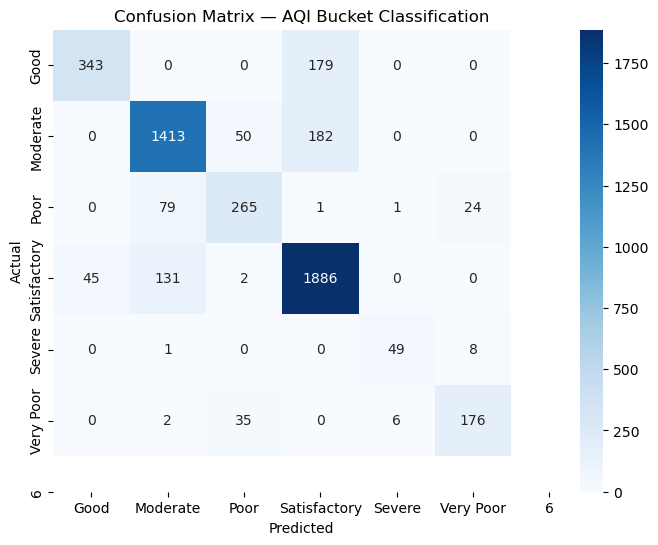

In [42]:
cm = confusion_matrix(y_test_clf, rf_clf_preds)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — AQI Bucket Classification")
plt.savefig(FIG_DIR + "confusion_matrix.png", dpi=150, bbox_inches='tight')
plt.show()


## 6. Model comparison summary

In [44]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest Regressor"],
    "MAE": [mean_absolute_error(y_test_reg, lr_preds), mean_absolute_error(y_test_reg, rf_reg_preds)],
    "RMSE": [np.sqrt(mean_squared_error(y_test_reg, lr_preds)), np.sqrt(mean_squared_error(y_test_reg, rf_reg_preds))],
    "R2": [r2_score(y_test_reg, lr_preds), r2_score(y_test_reg, rf_reg_preds)]
})
print("Regression comparison:")
results


Regression comparison:


,Model,MAE,RMSE,R2
0,Linear Regression,14.900836,25.810307,0.917899
1,Random Forest Regressor,11.826784,21.985484,0.940429


In [45]:
clf_results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest Classifier"],
    "Accuracy": [accuracy_score(y_test_clf, log_preds), accuracy_score(y_test_clf, rf_clf_preds)],
    "F1 (weighted)": [f1_score(y_test_clf, log_preds, average='weighted'),
                       f1_score(y_test_clf, rf_clf_preds, average='weighted')]
})
print("Classification comparison:")
clf_results


Classification comparison:


,Model,Accuracy,F1 (weighted)
0,Logistic Regression,0.812628,0.809512
1,Random Forest Classifier,0.847068,0.845067


## 7. Save the best models
Random Forest is saved for both tasks here — swap in whichever model scored best above if a different one wins on your run.

In [46]:
joblib.dump(rf_reg, "../models/random_forest_aqi_regressor.pkl")
joblib.dump(rf_clf, "../models/random_forest_aqi_classifier.pkl")

print("Saved models to ../models/")
print(" - random_forest_aqi_regressor.pkl")
print(" - random_forest_aqi_classifier.pkl")


Saved models to ../models/
 - random_forest_aqi_regressor.pkl
 - random_forest_aqi_classifier.pkl


## 8. Next steps
- If scores aren't strong enough yet: try `GridSearchCV`/`RandomizedSearchCV` to tune `n_estimators`, `max_depth`, `min_samples_split`
- Try `XGBoost`/`LightGBM` for a likely accuracy boost over Random Forest
- For a genuine time-series forecasting angle, an LSTM/GRU on the rolling-window features could be a good stretch goal for the demo
- Use `src/predict.py` to load the saved model and run inference on new input